In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    confusion_matrix, roc_auc_score, roc_curve, classification_report
)
import xgboost as xgb
import pickle
import os

# Settings
sns.set_palette("viridis")
plt.rcParams['figure.figsize'] = (12, 6)
plt.show()

print("Libraries Imported.")

Libraries Imported.


In [11]:
import pandas as pd
import pickle
import os

# Load split data (Paths corrected to project root)
X_train = pd.read_csv('data/processed/X_train.csv')
X_test = pd.read_csv('data/processed/X_test.csv')
y_train = pd.read_csv('data/processed/y_train.csv').values.ravel()
y_test = pd.read_csv('data/processed/y_test.csv').values.ravel()

# Load preprocessor
with open('models/preprocessor.pkl', 'rb') as f:
    preprocessor = pickle.load(f)

# Step 1: Transform features
X_train_proc = preprocessor.transform(X_train)
X_test_proc = preprocessor.transform(X_test)

print(f"Data loaded successfully!")
print(f"Training set shape: {X_train_proc.shape}")



Data loaded successfully!
Training set shape: (800, 20)


C:\Users\SRIDHAR RAO\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.7.2 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\SRIDHAR RAO\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\SRIDHAR RAO\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to

In [12]:
X_train_proc

array([[ 1.37941855,  0.68645799,  1.71775611, ...,  0.        ,
         1.        ,  0.        ],
       [-0.03991886,  1.37984991, -0.31681561, ...,  0.        ,
         1.        ,  0.        ],
       [-0.74958757, -0.00693392, -0.84295813, ...,  1.        ,
         0.        ,  1.        ],
       ...,
       [-0.74958757, -0.70032583,  1.43528955, ...,  1.        ,
         0.        ,  1.        ],
       [ 0.66974984, -0.70032583, -0.88980989, ...,  1.        ,
         0.        ,  1.        ],
       [-0.03991886, -0.70032583,  1.36910135, ...,  0.        ,
         1.        ,  0.        ]])

In [16]:
print("--- Starting Hyperparameter Tuning ---")

# 1. Logistic Regression
print("Tuning Logistic Regression...")
lr = LogisticRegression(max_iter=1000)
param_grid_lr = {'C': [0.1, 1, 10], 'penalty': ['l2']}
grid_lr = GridSearchCV(lr, param_grid_lr, cv=5, scoring='f1')
grid_lr.fit(X_train_proc, y_train)
lr_best = grid_lr.best_estimator_

# 2. Random Forest
print("Tuning Random Forest...")
rf = RandomForestClassifier(random_state=42)
param_grid_rf = {'n_estimators': [50, 100], 'max_depth': [None, 10, 20]}
grid_rf = GridSearchCV(rf, param_grid_rf, cv=5, scoring='f1')
grid_rf.fit(X_train_proc, y_train)
rf_best = grid_rf.best_estimator_

# 3. XGBoost
print("Tuning XGBoost...")
xgb_model = xgb.XGBClassifier(eval_metric='logloss', random_state=42)
param_grid_xgb = {'n_estimators': [50, 100], 'learning_rate': [0.1, 0.2], 'max_depth': [3, 5]}
grid_xgb = GridSearchCV(xgb_model, param_grid_xgb, cv=5, scoring='f1')
grid_xgb.fit(X_train_proc, y_train)
xgb_best = grid_xgb.best_estimator_

models = {'Logistic Regression': lr_best, 'Random Forest': rf_best, 'XGBoost': xgb_best}
print("Completed Tuning.")

--- Starting Hyperparameter Tuning ---
Tuning Logistic Regression...
Tuning Random Forest...
Tuning XGBoost...
Completed Tuning.


In [17]:
results_list = []

def evaluate_and_record(model, name, X, y):
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]
    
    metrics = {
        'Model': name,
        'Accuracy': accuracy_score(y, y_pred),
        'Precision': precision_score(y, y_pred),
        'Recall': recall_score(y, y_pred),
        'F1-Score': f1_score(y, y_pred),
        'ROC-AUC': roc_auc_score(y, y_prob)
    }
    return metrics, confusion_matrix(y, y_pred), y_prob

all_metrics = []
cm_dict = {}
prob_dict = {}

for name, model in models.items():
    metrics, cm, y_prob = evaluate_and_record(model, name, X_test_proc, y_test)
    all_metrics.append(metrics)
    cm_dict[name] = cm
    prob_dict[name] = y_prob

results_df = pd.DataFrame(all_metrics).sort_values(by='F1-Score', ascending=False)
results_df.style.background_gradient(cmap='Greens')

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.475000,0.500000,0.628571,0.556962,0.495639
2,XGBoost,0.485000,0.508772,0.552381,0.529680,0.459348
1,Random Forest,0.480000,0.504425,0.542857,0.522936,0.507569


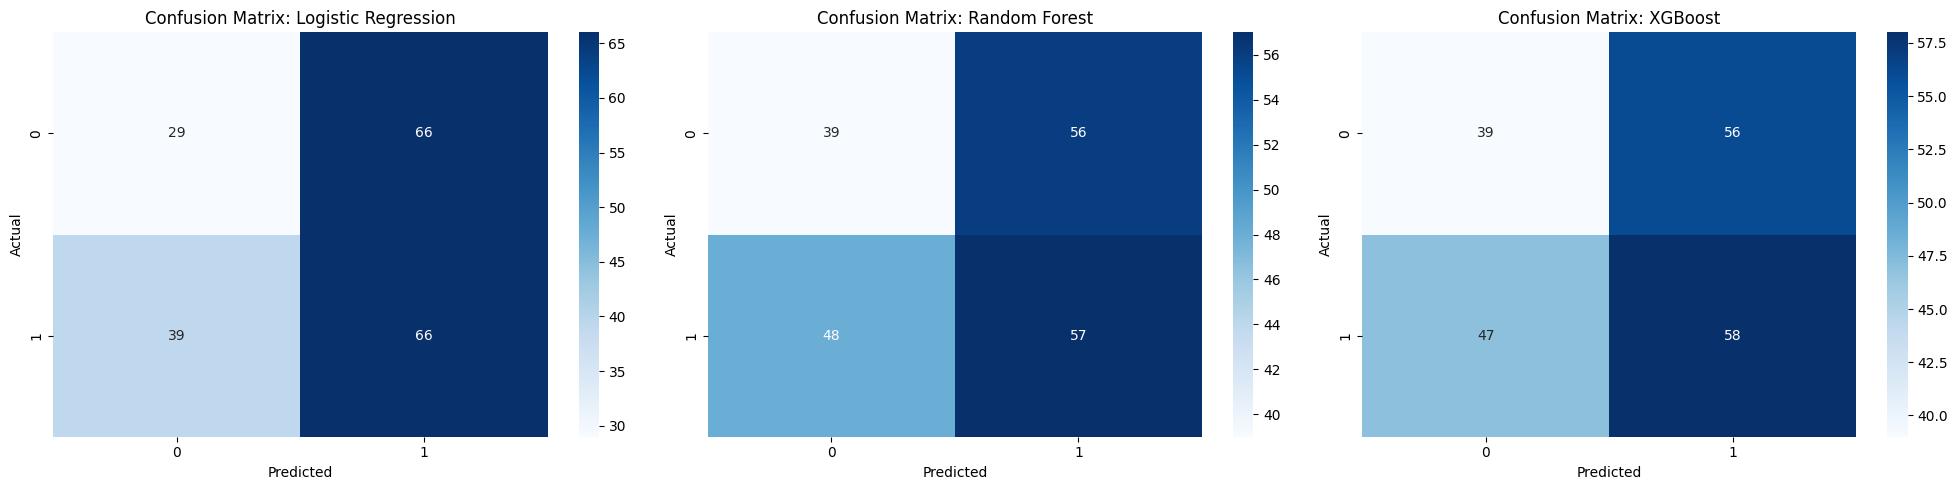

In [18]:
# Plot Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for i, (name, cm) in enumerate(cm_dict.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f'Confusion Matrix: {name}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
plt.tight_layout()
plt.show()